# Titanic Exercises

We will be working with a famous titanic data set for these exercises. Later on in the Machine Learning section of the course, we will revisit this data, and use it to predict survival rates of passengers. For now, we'll just focus on the visualization of the data with seaborn.

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [58]:
sns.set_style('whitegrid')

In [59]:
df = sns.load_dataset('titanic')

In [60]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


<Axes: >

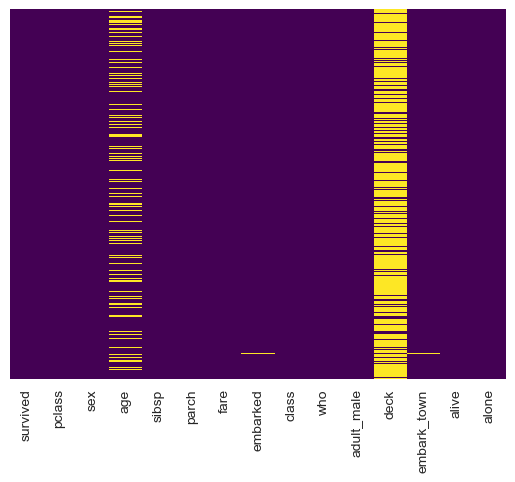

In [62]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [63]:
df['fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

<Axes: xlabel='fare', ylabel='Count'>

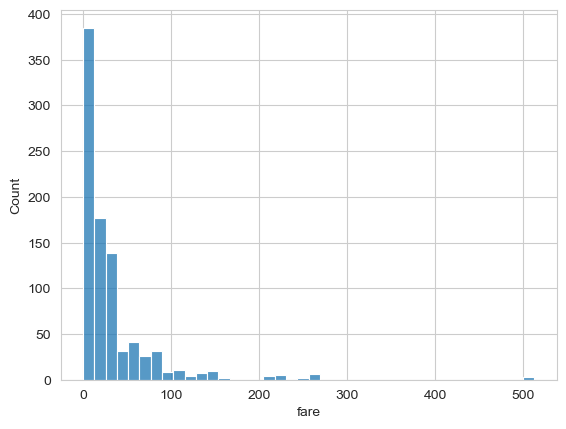

In [64]:
sns.histplot(df['fare'], bins=40)

<Axes: xlabel='fare', ylabel='Count'>

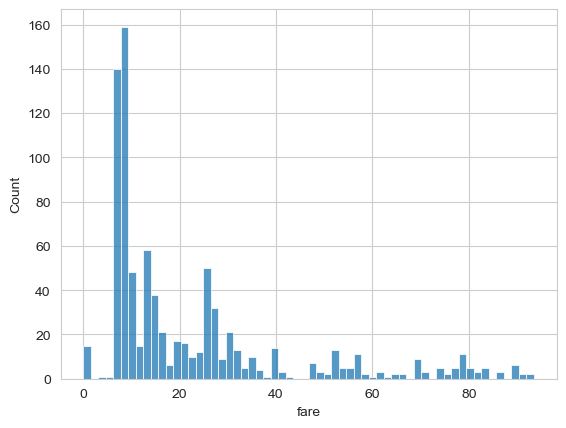

In [65]:
filtered_data = df[df['fare'] < 100]
sns.histplot(filtered_data['fare'], bins=60)

In [66]:
pd.crosstab(df["survived"], df["alive"])

alive,no,yes
survived,,
0,549,0
1,0,342


<Axes: xlabel='alive', ylabel='count'>

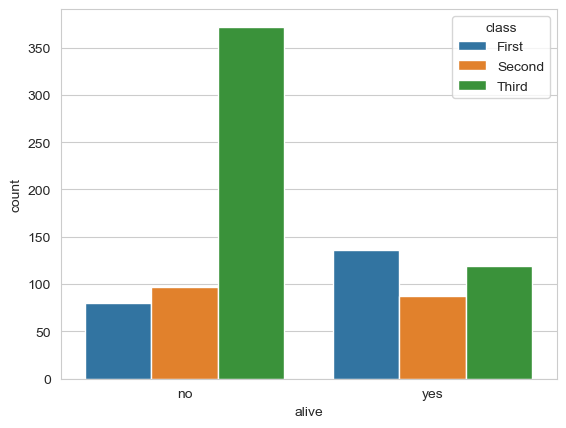

In [67]:
sns.countplot(x='alive', hue='class', data=df)

<Axes: xlabel='class', ylabel='count'>

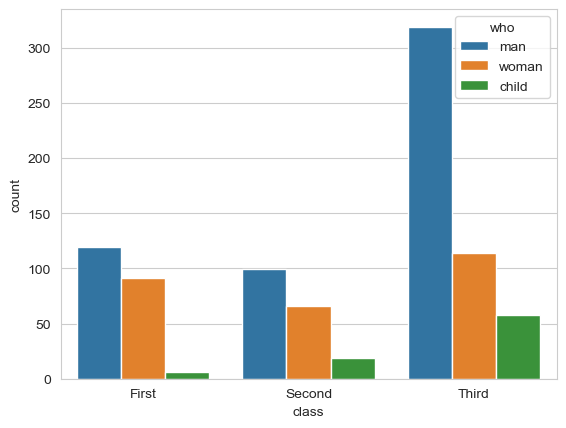

In [68]:
sns.countplot(x='class', data=df, hue='who')

<Axes: xlabel='alive', ylabel='count'>

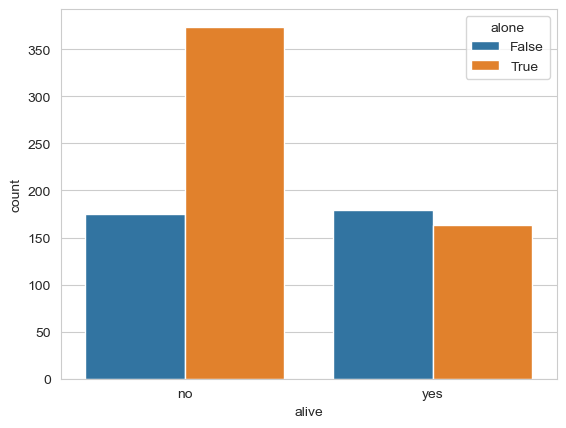

In [69]:
sns.countplot(x='alive', hue='alone', data=df)

<Axes: xlabel='class', ylabel='age'>

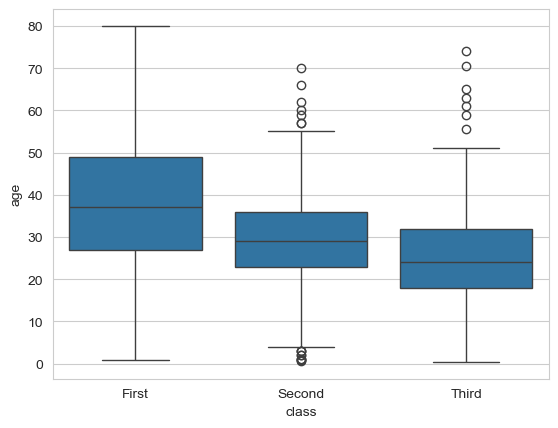

In [71]:
sns.boxplot(x='class', y='age', data=df)

<Axes: xlabel='class', ylabel='age'>

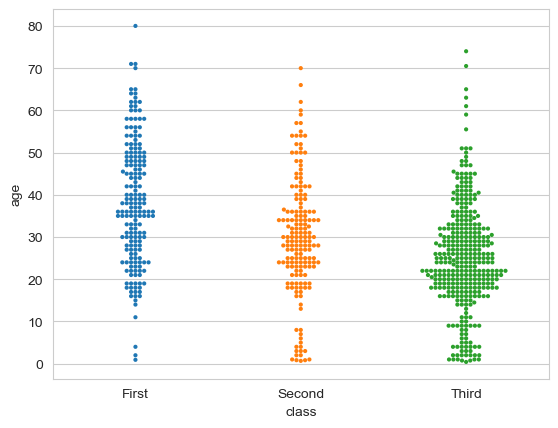

In [72]:
sns.swarmplot(x='class', y='age', data=df, hue='class', size=3)

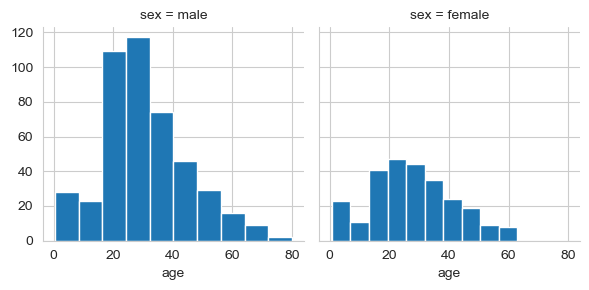

In [80]:
g = sns.FacetGrid(data=df, col='sex')
g.map(plt.hist, 'age')

<Axes: xlabel='class', ylabel='count'>

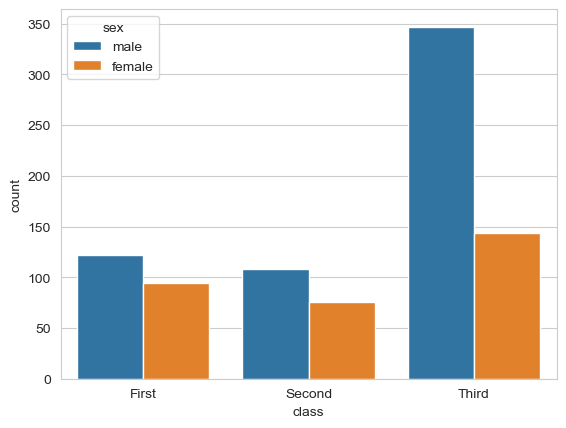

In [73]:
sns.countplot(x='class', data=df, hue='sex')

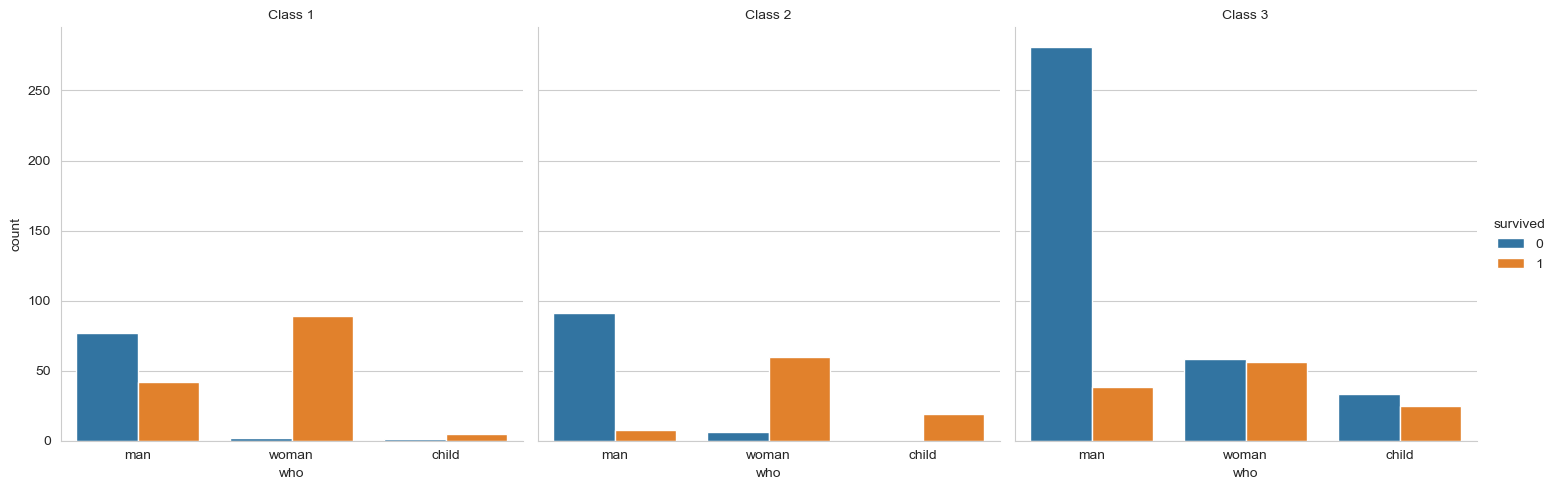

In [74]:
g = sns.catplot(x='who', hue='survived', col='pclass', data=df, kind='count')
g.set_titles("Class {col_name}")

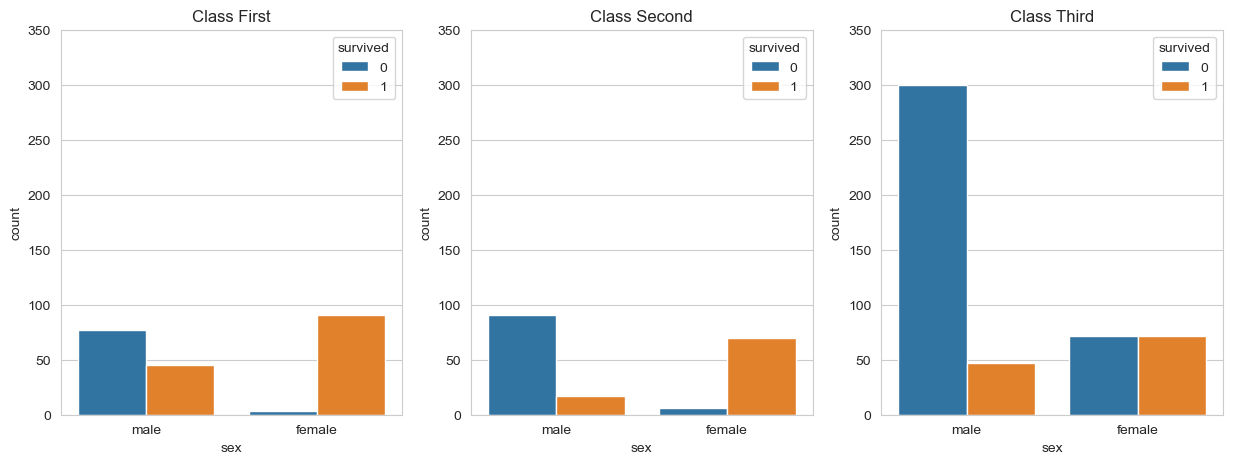

In [75]:
fig, axes = plt.subplots(1, df["class"].nunique(), figsize=(15, 5))
for i, cls in enumerate(sorted(df["class"].unique())):
    sns.countplot(x='sex', data=df[df['class']==cls], hue='survived', order=["male", "female"], ax=axes[i])
    axes[i].set_title(f"Class {cls}")
    axes[i].set_ylim(0, 350)

<Axes: >

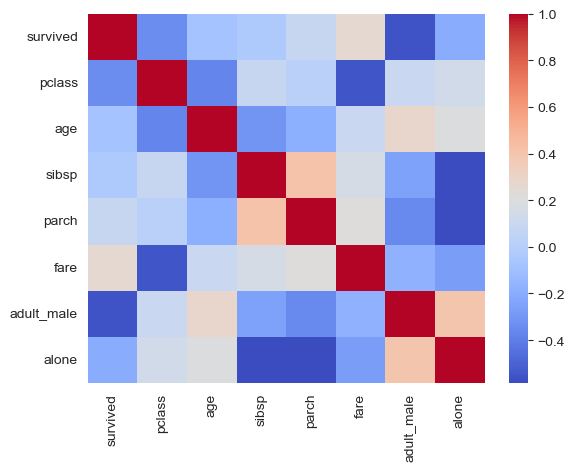

In [76]:
tc = df.corr(numeric_only=True)
sns.heatmap(tc, cmap='coolwarm')